# 🟡 Project - Penguin Species Multiclass Tree (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Classify three penguin species from morphology; identify which measurements
field teams should prioritize collecting.

End-to-end: load CSV → EDA → processing → criterion/depth grid → tuned tree +
importances.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, classification_report)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

def get_data(fname, url):
    f = ML_ROOT / "data" / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

### 2. Data loading


In [2]:
pen = get_data(
    "penguins.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv",
)
print("rows before:", len(pen))
pen = pen.dropna()                          # few incomplete rows → drop, documented
print("rows after :", len(pen))

using local -> penguins.csv
rows before: 344
rows after : 333


### 3. Exploratory Data Analysis


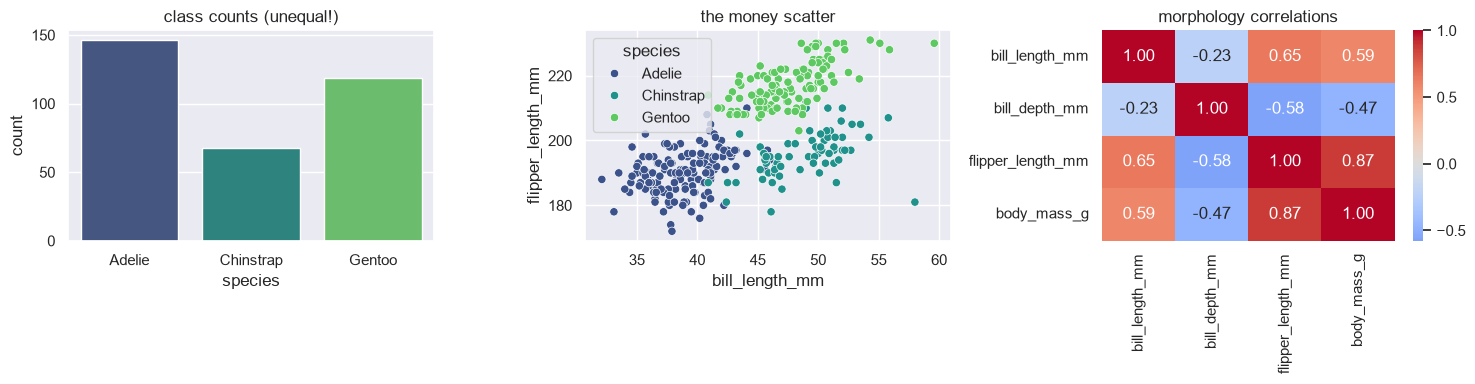

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="species", data=pen, ax=axes[0],
              palette="viridis", hue="species", legend=False)
axes[0].set_title("class counts (unequal!)")

sns.scatterplot(data=pen, x="bill_length_mm", y="flipper_length_mm",
                hue="species", palette="viridis", ax=axes[1])
axes[1].set_title("the money scatter")

corr = pen.select_dtypes("number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[2])
axes[2].set_title("morphology correlations")
plt.tight_layout(); plt.show()

print(pen.species.value_counts())

### 4. Data processing


In [4]:
y = pen["species"]
X = pd.get_dummies(pen.drop(columns="species"),
                   columns=["island", "sex"], drop_first=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

### 5. Model training - gini vs entropy across depths


best: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2} | CV 0.9758
test acc 0.9762 | macro-F1 0.9797
              precision    recall  f1-score   support

      Adelie       0.95      1.00      0.97        37
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      0.93      0.97        30

    accuracy                           0.98        84
   macro avg       0.98      0.98      0.98        84
weighted avg       0.98      0.98      0.98        84



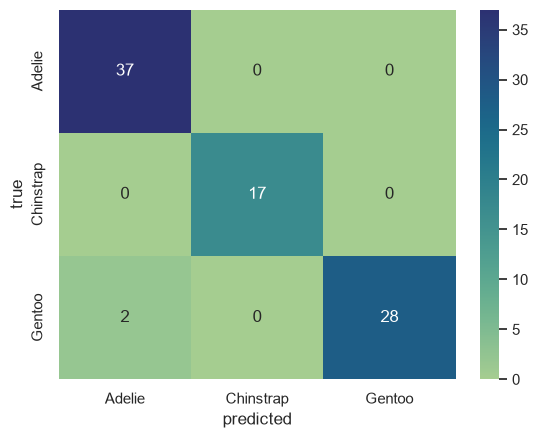

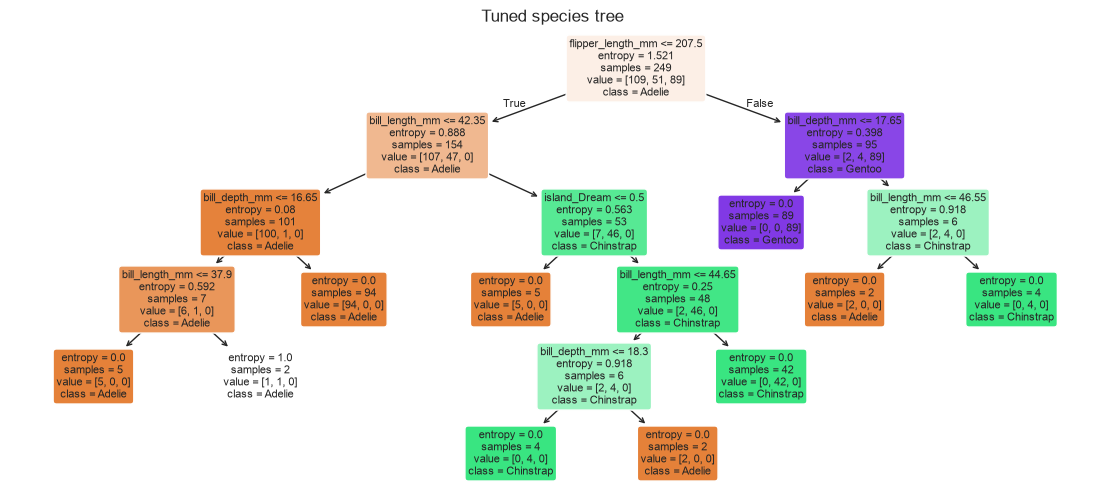

In [5]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"criterion": ["gini", "entropy"],
     "max_depth": [3, 4, 5],
     "min_samples_leaf": [2, 5, 10]},
    cv=5)
grid.fit(X_tr, y_tr)
best = grid.best_estimator_
pred = best.predict(X_te)

print("best:", grid.best_params_, f"| CV {grid.best_score_:.4f}")
print(f"test acc {accuracy_score(y_te, pred):.4f} "
      f"| macro-F1 {f1_score(y_te, pred, average='macro'):.4f}")
print(classification_report(y_te, pred))

sns.heatmap(confusion_matrix(y_te, pred, labels=best.classes_),
            annot=True, fmt="d", cmap="crest",
            xticklabels=best.classes_, yticklabels=best.classes_)
plt.xlabel("predicted"); plt.ylabel("true"); plt.show()

plt.figure(figsize=(14, 6))
plot_tree(best, feature_names=X.columns, class_names=best.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title("Tuned species tree"); plt.show()

### 6. Findings - measurement priorities


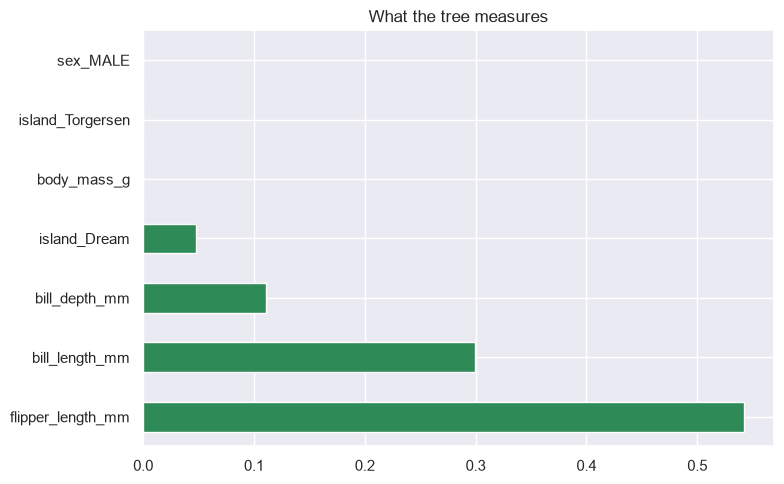

,importance
flipper_length_mm,0.542
bill_length_mm,0.300
bill_depth_mm,0.111
island_Dream,0.047


In [6]:
imp = pd.Series(best.feature_importances_, index=X.columns) \
        .sort_values(ascending=False)
colors = ["seagreen" if v > .01 else "lightgray" for v in imp]
imp.plot(kind="barh", color=colors[::-1][:len(imp)][::-1], figsize=(8, 5))
plt.title("What the tree measures"); plt.tight_layout(); plt.show()
display(imp.head(4).round(3).to_frame("importance"))

### Findings

1. ~99% accuracy; bill length + flipper length carry nearly everything.
2. Gini vs entropy differ negligibly - default gini is fine.
3. Island dummies proxy geography; flag before biological claims.

### Takeaway
Trees double as feature-priority reports for field protocols.